In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

results_dir = "/home/ligong1/mednlp/ethos/ethos-paper/results/icu_readmission_ethos_official_test"

In [5]:

results_path = Path(results_dir)
json_files = glob.glob(str(results_path / "*.json"))

token_distances = []

for file_path in json_files:
        with open(file_path, 'r') as f:
            data = json.load(f)
            
            for entry in data:
                if "stop_reason" in entry and entry["stop_reason"] == "length_limit":
                    token_distances.append(entry["token_dist"])

In [6]:
df = pd.Series(token_distances)
    
print("--- ICU Readmission Token Distance Distribution ---")
print(df.describe(percentiles=[.25, .5, .75, .8, .9, .95]))
    


--- ICU Readmission Token Distance Distribution ---
count    2487.000000
mean      154.522316
std       376.768113
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
80%        73.800000
90%       681.600000
95%      1117.700000
max      1912.000000
dtype: float64


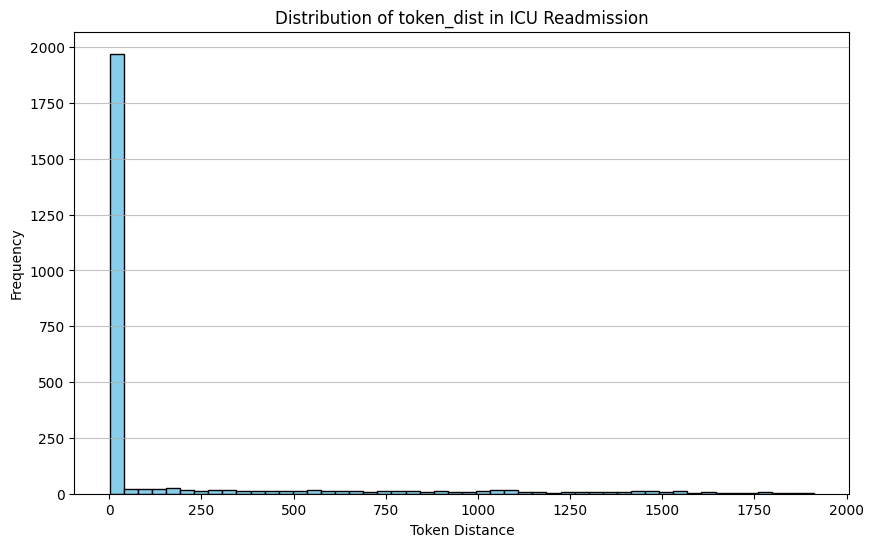

In [7]:
# Plotting
plt.figure(figsize=(10, 6))
plt.hist(token_distances, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of token_dist in ICU Readmission')
plt.xlabel('Token Distance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()